# 03 — EEGNet on raw 64-channel epochs

End-to-end CNN (Lawhern 2018) — no hand-crafted features. Block 2 learns
CSP-like spatial filters across all 64 channels per temporal-frequency band.
See `PIPELINE_PLAN.md` §7 for the architecture.

GPU is recommended; the script auto-selects CUDA → MPS → CPU.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
print('CUDA:', torch.cuda.is_available(), '| MPS:', torch.backends.mps.is_available())

from scripts.run_03_eegnet import main as run_eegnet


CUDA: False | MPS: True


## Train + evaluate (both windows, then pick winner)

In [2]:
run_eegnet()

Device: mps

=== Window w0.0-4.0 ===
  epochs: train=1849 val=340 test=296
  params: 2770 | input shape: (64, 641)
  epoch   1 | train_loss 0.7016 | val_loss 0.6972 | val_macroF1 0.4474 | val_acc 0.4853  *
  epoch   2 | train_loss 0.6992 | val_loss 0.6958 | val_macroF1 0.5002 | val_acc 0.5029  *
  epoch   4 | train_loss 0.6918 | val_loss 0.6913 | val_macroF1 0.5097 | val_acc 0.5118  *
  epoch   6 | train_loss 0.6879 | val_loss 0.6842 | val_macroF1 0.5432 | val_acc 0.5441  *
  epoch   7 | train_loss 0.6775 | val_loss 0.6733 | val_macroF1 0.5435 | val_acc 0.5471  *
  epoch   8 | train_loss 0.6706 | val_loss 0.6656 | val_macroF1 0.5750 | val_acc 0.5765  *
  epoch  10 | train_loss 0.6555 | val_loss 0.6554 | val_macroF1 0.5871 | val_acc 0.5882  *
  epoch  11 | train_loss 0.6458 | val_loss 0.6501 | val_macroF1 0.6141 | val_acc 0.6147  *
  epoch  13 | train_loss 0.6348 | val_loss 0.6422 | val_macroF1 0.6261 | val_acc 0.6294  *
  epoch  14 | train_loss 0.6404 | val_loss 0.6313 | val_macroF1 0.

## Inspect saved results

In [3]:
import json
result = json.loads((ROOT / 'reports' / 'eegnet_results.json').read_text())
print('Architecture:', result['model_config']['architecture'])
print('# params    :', result['model_config']['n_params'])
print('Device      :', result['model_config']['training']['device'])
print('Winning window:', result['winning_window'])
print('Test metrics:')
for k, v in result['test_metrics'].items():
    print(f'  {k}: {v}')
print('Per-window val:')
for w in result['windows_evaluated']:
    print(f"  window {w['window']}: val macroF1 {w['val_macro_f1']:.4f}  acc {w['val_accuracy']:.4f}  ({w['training_time_sec']:.1f}s)")


Architecture: EEGNet (Lawhern 2018) F1=8 D=2 F2=16 kernel=64 dropout=0.5
# params    : 2770
Device      : mps
Winning window: [0.0, 4.0]
Test metrics:
  accuracy: 0.7094594594594594
  macro_f1: 0.708808053077099
  per_class_f1: [0.6950354609929078, 0.7225806451612903]
  confusion_matrix: [[98, 48], [38, 112]]
Per-window val:
  window [0.0, 4.0]: val macroF1 0.7757  acc 0.7765  (233.1s)
  window [0.5, 2.5]: val macroF1 0.6540  acc 0.6542  (87.7s)


## Training curves and confusion matrix

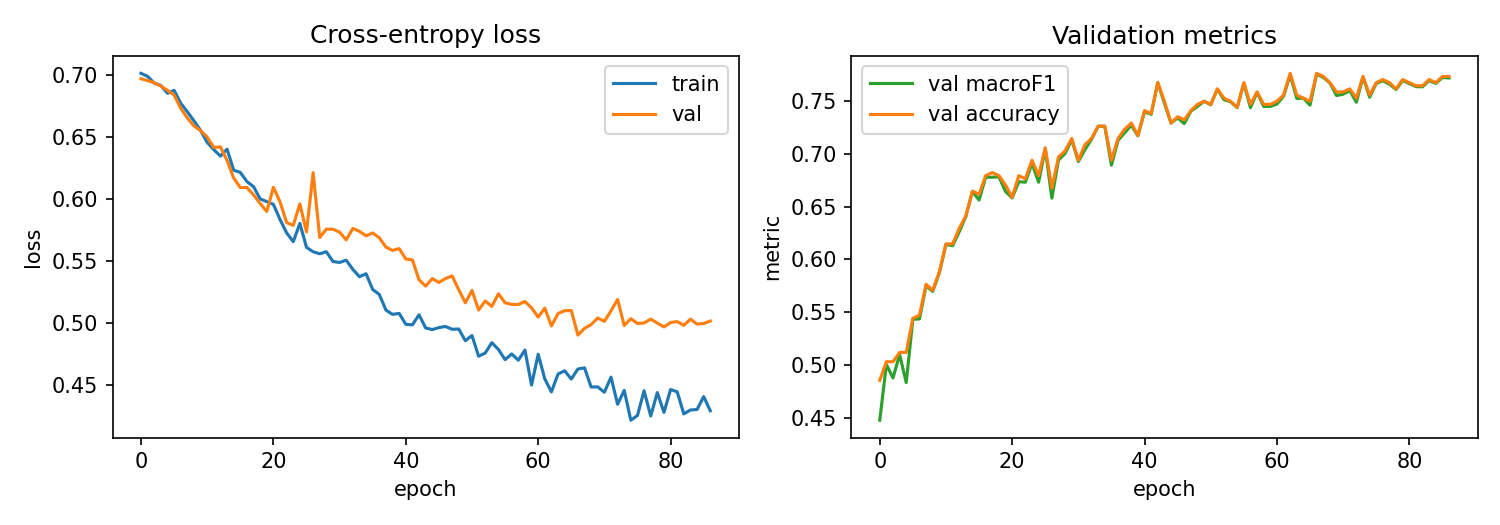

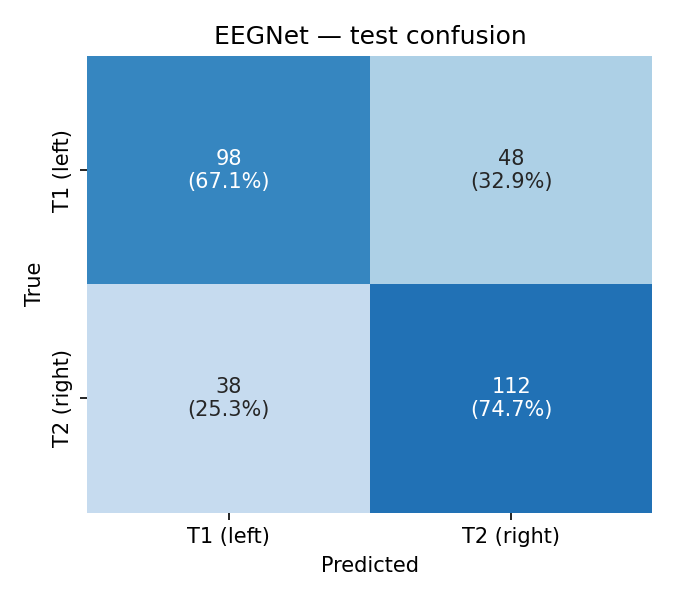

In [4]:
from IPython.display import Image, display
display(Image(str(ROOT / 'reports' / 'figures' / 'eegnet_training_curves.png')))
display(Image(str(ROOT / 'reports' / 'figures' / 'eegnet_confusion.png')))
